<a href="https://colab.research.google.com/github/wtangxian/ChibiTest/blob/master/AIGP_Lab8_2D_Doggy_kick_Ball.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# === GitHub Authentication Cell ===
import getpass, os

# Prompt for your GitHub Personal Access Token (PAT)
GITHUB_TOKEN = getpass.getpass("Enter your GitHub PAT: ")

# Store it in the environment for later use
os.environ["GITHUB_TOKEN"] = GITHUB_TOKEN

# Configure Git identity (replace with your own email/name)
!git config --global user.email "your_email@example.com"
!git config --global user.name "Your Name"

print("✅ GitHub authentication set up for this Colab session.")


Enter your GitHub PAT: ··········
✅ GitHub authentication set up for this Colab session.


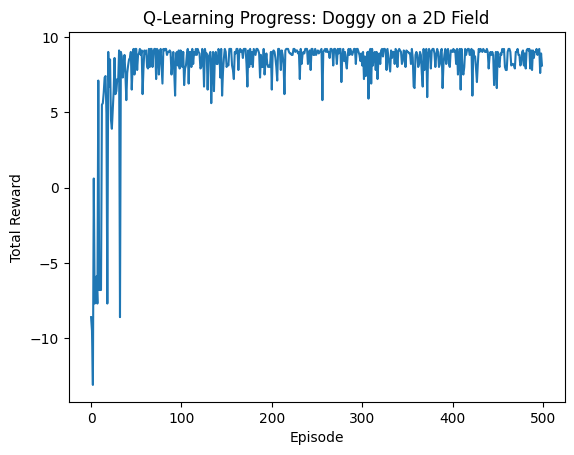


Learned Policy:

[['BALL' 'L' 'L' 'L' 'L']
 ['U' 'U' 'U' 'X' 'D']
 ['U' 'L' 'X' 'D' 'D']
 ['U' 'L' 'L' 'L' 'L']
 ['U' 'U' 'U' 'U' 'L']]


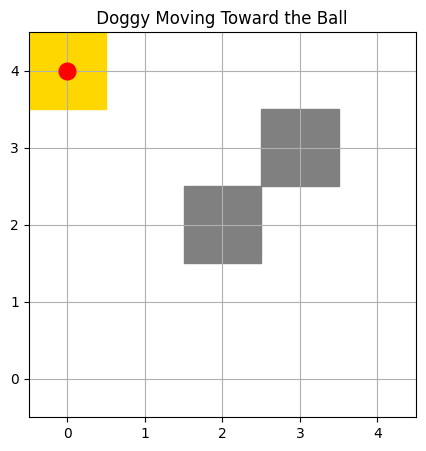

In [2]:
# AIGP_Lab8 2D Football Field

import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# --- Environment setup ---
grid_size = 5
num_actions = 5
actions = ["up", "down", "left", "right", "kick"]

alpha = 0.1
gamma = 0.9
epsilon = 0.2
num_episodes = 500

ball_pos = (0, 0)
obstacles = [(2, 2), (1, 3)]

q_table = np.zeros((grid_size, grid_size, num_actions))

def choose_action(state):
    if random.random() < epsilon:
        return random.choice(actions)
    else:
        x, y = state
        return actions[np.argmax(q_table[x, y])]

def get_reward(state, action):
    if action == "kick":
        if state == ball_pos:
            return 10
        else:
            return -1
    elif state in obstacles:
        return -5
    else:
        return -0.1

def transition(state, action):
    x, y = state
    if action == "up" and x > 0:
        x -= 1
    elif action == "down" and x < grid_size - 1:
        x += 1
    elif action == "left" and y > 0:
        y -= 1
    elif action == "right" and y < grid_size - 1:
        y += 1
    elif action == "kick":
        return state
    if (x, y) in obstacles:
        return state
    return (x, y)

def update_q(state, action, reward, next_state):
    a_idx = actions.index(action)
    x, y = state
    nx, ny = next_state
    max_next_q = np.max(q_table[nx, ny])
    q_table[x, y, a_idx] += alpha * (reward + gamma * max_next_q - q_table[x, y, a_idx])

# --- Training ---
episode_rewards = []
for ep in range(num_episodes):
    state = (grid_size - 1, grid_size - 1)
    total_reward = 0
    for step in range(50):
        action = choose_action(state)
        reward = get_reward(state, action)
        next_state = transition(state, action)
        update_q(state, action, reward, next_state)
        total_reward += reward
        state = next_state
        if state == ball_pos and action == "kick":
            break
    episode_rewards.append(total_reward)

# --- Show training progress ---
plt.figure()
plt.plot(episode_rewards)
plt.title("Q-Learning Progress: Doggy on a 2D Field")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.show()

# --- Visualize Learned Policy ---
policy = np.empty((grid_size, grid_size), dtype='<U6')
for i in range(grid_size):
    for j in range(grid_size):
        if (i, j) == ball_pos:
            policy[i, j] = "BALL"
        elif (i, j) in obstacles:
            policy[i, j] = "X"
        else:
            best_action = actions[np.argmax(q_table[i, j])]
            policy[i, j] = best_action[0].upper()

print("\nLearned Policy:\n")
print(policy)

# --- Simulation of learned path ---
def simulate_path():
    path = []
    state = (grid_size - 1, grid_size - 1)
    for _ in range(20):
        path.append(state)
        if state == ball_pos:
            break
        action = actions[np.argmax(q_table[state[0], state[1]])]
        state = transition(state, action)
    return path

path = simulate_path()

# --- Visualization with animation ---
fig, ax = plt.subplots(figsize=(5,5))
ax.set_xlim(-0.5, grid_size-0.5)
ax.set_ylim(-0.5, grid_size-0.5)
ax.set_xticks(range(grid_size))
ax.set_yticks(range(grid_size))
ax.grid(True)

# Draw static elements
for obs in obstacles:
    ax.add_patch(plt.Rectangle((obs[1]-0.5, grid_size-1-obs[0]-0.5), 1, 1, color='gray'))
ax.add_patch(plt.Rectangle((ball_pos[1]-0.5, grid_size-1-ball_pos[0]-0.5), 1, 1, color='gold'))

dog_marker, = ax.plot([], [], 'ro', markersize=12)

def init():
    dog_marker.set_data([], [])
    return dog_marker,

def update(frame):
    state = path[frame]
    dog_marker.set_data([state[1]], [grid_size-1-state[0]]) # Wrap coordinates in lists
    return dog_marker,

ani = animation.FuncAnimation(fig, update, frames=len(path),
                              init_func=init, interval=700, blit=True, repeat=False)
plt.title(" Doggy Moving Toward the Ball ")

# --- Display animation inline (for Colab) ---
from IPython.display import HTML
HTML(ani.to_jshtml())